# H₀ connectivity · fixed vertex births
### A visual walkthrough of 0–1 | 2–3

**Decision:** all matched vertices exist at $t=0$; edges enter at $f(e)=1-p_e$.
Finite merge intervals supervise connectivity. The surviving $(0,\infty)$ bar has no learnable coordinate.

Read the figures from top to bottom. Code cells carry `hide-input` metadata; all outputs are saved. Run with Python 3.10+, NumPy, Matplotlib, PyTorch, IPython and Jupyter. Keep the companion `graph_h0_fixed_births.py` beside this notebook.

*Research demonstration; the training-package loss has not been changed.*

In [1]:
from pathlib import Path
import os, sys
HERE = Path.cwd()
for folder in (HERE, HERE / "examples" / "experiments"):
    if (folder / "graph_h0_fixed_births.py").exists():
        sys.path.insert(0, str(folder))
        break
else:
    raise FileNotFoundError("Place graph_h0_fixed_births.py beside this notebook.")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/h0-fixed-mpl")
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from IPython.display import display, HTML
from graph_h0_fixed_births import (
    EXAMPLE, TRUTH, complete_edges, from_probabilities, target_graph,
    minimum_union, persistence, components_at, induced_matching,
    scalar_loss, loss_terms, differentiable_loss, self_check,
)
plt.rcParams.update({
    "figure.dpi": 125, "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.spines.top": False,
    "axes.spines.right": False, "font.family": "DejaVu Sans",
    "figure.facecolor": "#f5f7fa", "axes.facecolor": "#f5f7fa",
    "axes.labelcolor": "#213249", "text.color": "#213249",
})
BLUE, TEAL, RED, GOLD, GRAY = "#2563eb", "#008579", "#d94b5a", "#b97808", "#8491a4"
P = from_probabilities(4, EXAMPLE)
G = target_graph(P, TRUTH)
U = minimum_union(P, G)
M = induced_matching(P, G)
E = torch.tensor(P.edges, dtype=torch.long)
labels = [f"{a}{b}" for a,b in P.edges]
POS = {0:(0,1), 1:(1,1), 2:(1,0), 3:(0,0)}
EXPORT_FIGURES = False  # Turn on to export each presentation panel as PNG.
def finish(fig, name):
    if EXPORT_FIGURES:
        out = Path("h0_figures"); out.mkdir(exist_ok=True)
        fig.savefig(out / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
def partition(cs):
    return " | ".join("{" + ",".join(map(str,c)) + "}" for c in cs) or "no active vertices"
def graph(ax, g, t=.5, title="", annotate=False):
    active = {v for v,b in enumerate(g.births) if b <= t}
    for e,f in zip(g.edges,g.values):
        a,b=e
        if f > t: continue
        x,y=POS[a],POS[b]
        color = TEAL if e in TRUTH else RED
        rad = 0  # Straight square sides and diagonals.
        patch=FancyArrowPatch(x,y,arrowstyle="-",connectionstyle=f"arc3,rad={rad}",
                              linewidth=2.6,color=color,alpha=.8,zorder=1)
        ax.add_patch(patch)
        if annotate and e in ((0,1),(1,2),(2,3)):
            dx,dy = {(0,1):(0,.20), (1,2):(.18,0), (2,3):(0,-.20)}[e]
            ax.text((x[0]+y[0])/2+dx,(x[1]+y[1])/2+dy,f"p={1-f:.2f}",
                    ha="left" if e==(1,2) else "center",va="center",color=color,fontsize=10)
    for v,xy in POS.items():
        if v in active:
            ax.scatter(*xy,s=470,color="white",edgecolor=BLUE,linewidth=2,zorder=3)
            ax.text(*xy,str(v),ha="center",va="center",weight="bold",zorder=4)
        else:
            ax.scatter(*xy,s=400,facecolor="none",edgecolor="#ccd4e0",linestyle=":",zorder=2)
    ax.set(xlim=(-.55,1.85),ylim=(-.65,1.5),aspect="equal")
    ax.set_title(title,pad=5)
    ax.text(.5,-.50,partition(components_at(g,t)),ha="center",fontsize=10)
    ax.axis("off")
def bars(ax, result, title, essential=True):
    ps = sorted(result.pairs,key=lambda a:a.vertex)
    for j,a in enumerate(ps):
        ax.plot([a.birth,a.death],[j,j],color=BLUE,lw=5,solid_capstyle="round")
        ax.scatter([a.birth,a.death],[j,j],s=24,c=BLUE,zorder=3)
        ax.text(a.death+.025,j,f"{a.death:.2f}",va="center",fontsize=10)
    yt=[f"r={a.vertex} · edge {a.death_edge[0]}{a.death_edge[1]}" for a in ps]
    if essential:
        j=len(ps)
        ax.annotate("",xy=(1.1,j),xytext=(result.essential[1],j),
                    arrowprops=dict(arrowstyle="->",color=GRAY,lw=1.6,linestyle="--"))
        yt.append(f"r={result.essential[0]} · essential")
    ax.set_yticks(range(len(yt)),yt)
    ax.set(xlim=(-.035,1.18),ylim=(-.65,len(yt)-.35),xlabel="filtration t")
    ax.invert_yaxis()
    ax.set_title(title,pad=15)
    ax.axvline(1,color=GRAY,lw=.8,ls=":")
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y",length=0)
def table(ax, columns, rows, title="", widths=None):
    ax.axis("off"); ax.set_title(title,pad=16)
    tab=ax.table(cellText=rows,colLabels=columns,cellLoc="center",
                 colWidths=widths,loc="center")
    tab.auto_set_font_size(False);tab.set_fontsize(10);tab.scale(1,2.05)
    for (r,c),cell in tab.get_celld().items():
        cell.set_edgecolor("white")
        cell.set_facecolor("#dce7f6" if r==0 else ("#edf2f8" if r%2 else "white"))
        if r==0:cell.set_text_props(weight="bold")
    return tab
display(HTML("<style>.jp-OutputArea-output{overflow-x:auto} .jp-RenderedHTMLCommon{max-width:1100px}</style>"))


## 01 · The same four matched vertices

GT contains two separate vessels, \(01\) and \(23\). Prediction already has the right components at \(p\geq0.5\), but its confidences can improve. Gray absent vertices in later legacy panels mean “not born yet.”

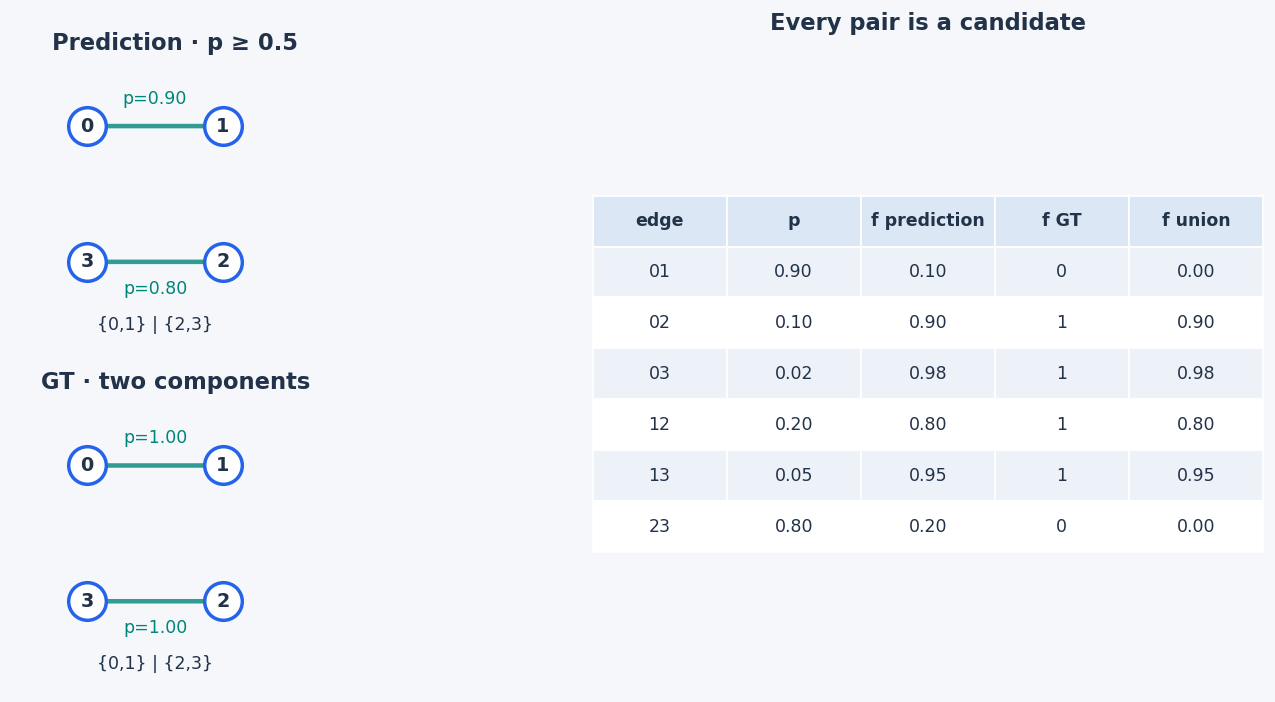

In [2]:
fig = plt.figure(figsize=(12,5.5),layout="constrained")
gs=fig.add_gridspec(2,2,width_ratios=[1.2,1])
graph(fig.add_subplot(gs[0,0]),P,.5,"Prediction · p ≥ 0.5",True)
graph(fig.add_subplot(gs[1,0]),G,.5,"GT · two components",True)
rows=[[f"{a}{b}",f"{EXAMPLE[(a,b)]:.2f}",f"{f:.2f}",f"{g:.0f}",f"{u:.2f}"]
      for (a,b),f,g,u in zip(P.edges,P.values,G.values,U.values)]
table(fig.add_subplot(gs[:,1]),["edge","p","f prediction","f GT","f union"],rows,
      "Every pair is a candidate")
finish(fig,"01_common_graph")

## 02 · What exists at each threshold?

Every vertex is present from the start. \(K_u^t=K_p^t\cup K_{GT}^t\).
At \(T=1\), artificial non-GT candidate edges connect the target too; those terminal merges encode its earlier separation.

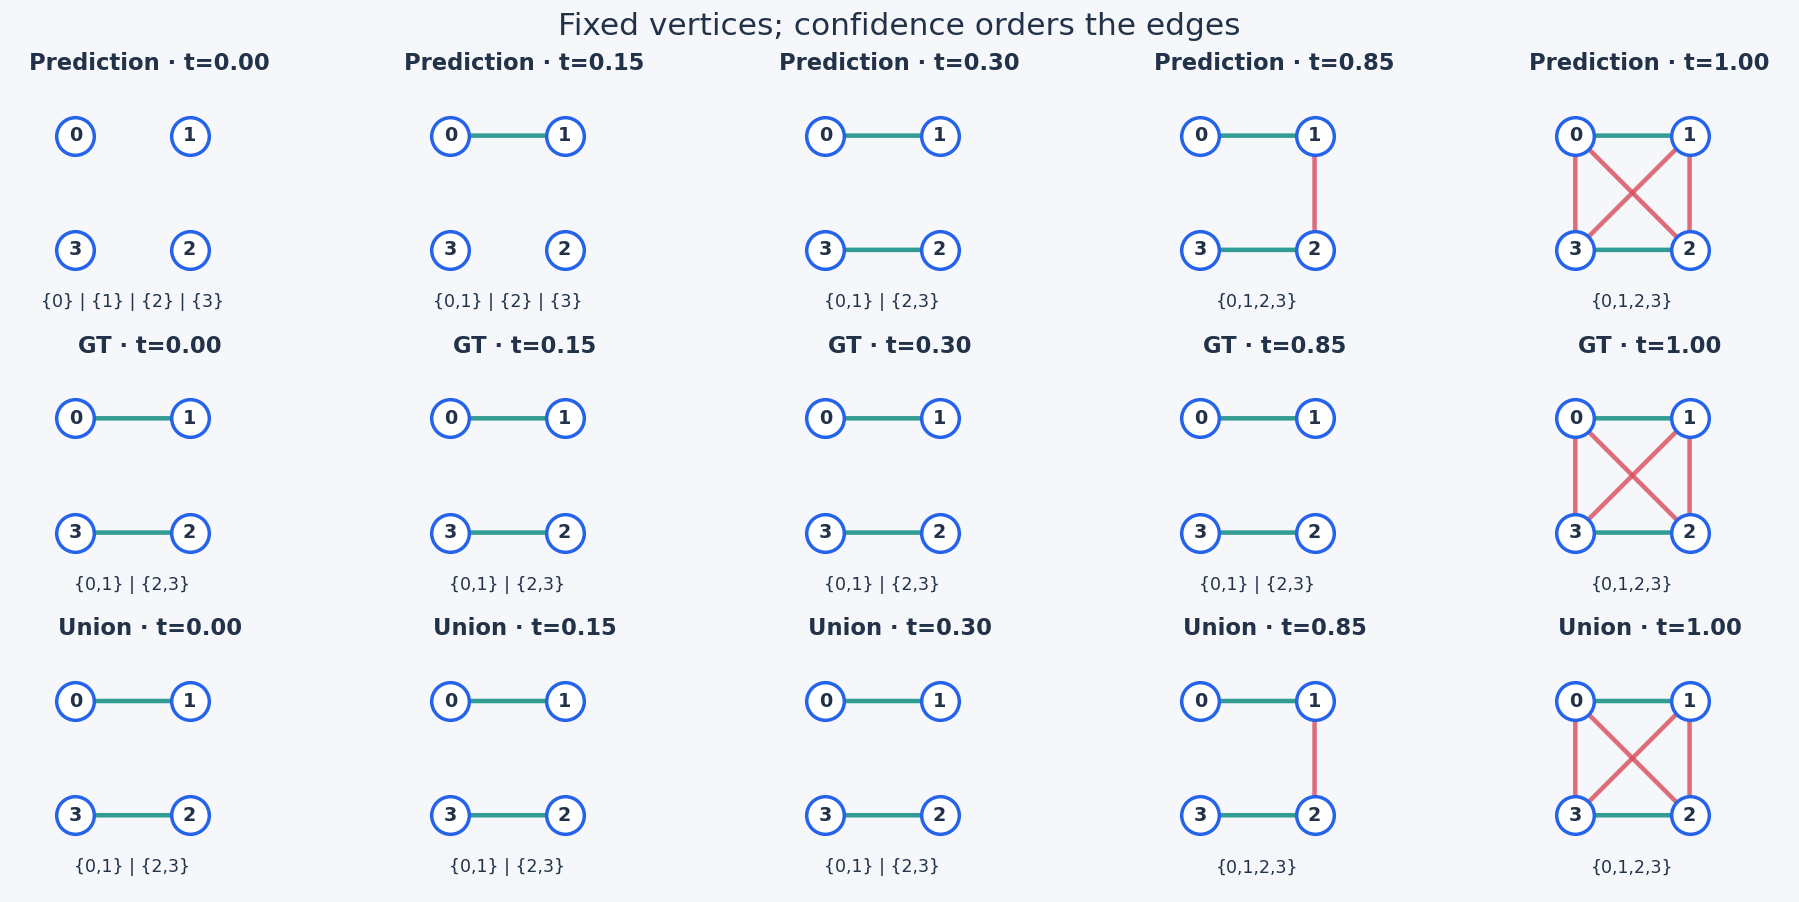

In [3]:
fig,axs=plt.subplots(3,5,figsize=(15,7.1),layout="constrained")
for row,(g,name) in enumerate(((P,"Prediction"),(G,"GT"),(U,"Union"))):
    for col,t in enumerate((0.,.15,.30,.85,1.)):
        graph(axs[row,col],g,t,f"{name} · t={t:.2f}")
fig.suptitle("Fixed vertices; confidence orders the edges",fontsize=18)
finish(fig,"02_filtration")

## 03 · Where the missing supervision comes from

Previously, vertex \(1\) appeared together with edge \(01\): its interval had zero length.
Now vertex \(1\) starts at zero, so edge \(01\) ends a finite interval \((0,0.10)\).
**The surviving root \(0\) is still omitted from the loss; edge \(01\) is now supervised through the death of root \(1\).**

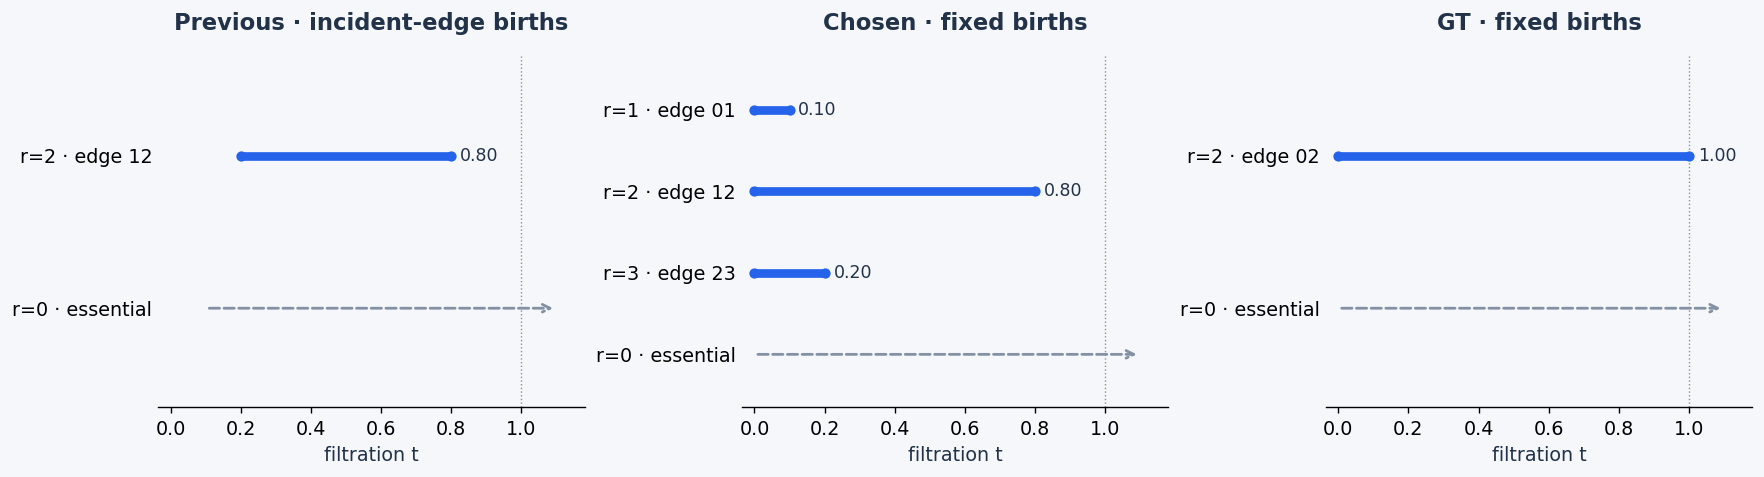

In [4]:
oldP=from_probabilities(4,EXAMPLE,vertex_mode="incident")
oldG=target_graph(oldP,TRUTH,vertex_mode="incident")
oldM=induced_matching(oldP,oldG)
fig,axs=plt.subplots(1,3,figsize=(14,3.7),layout="constrained")
bars(axs[0],persistence(oldP),"Previous · incident-edge births")
bars(axs[1],M.prediction,"Chosen · fixed births")
bars(axs[2],M.target,"GT · fixed births")
finish(fig,"03_barcodes")

## 04 · How the union chooses correspondence

First compute ordinary source pairs and index them by killed birth vertex.
Then sweep the **comparison forest** with the source elder orders. These auxiliary union-find structures follow comparison edges; they are not source graphs at the same time.
Zero-length comparison merges still update every forest.

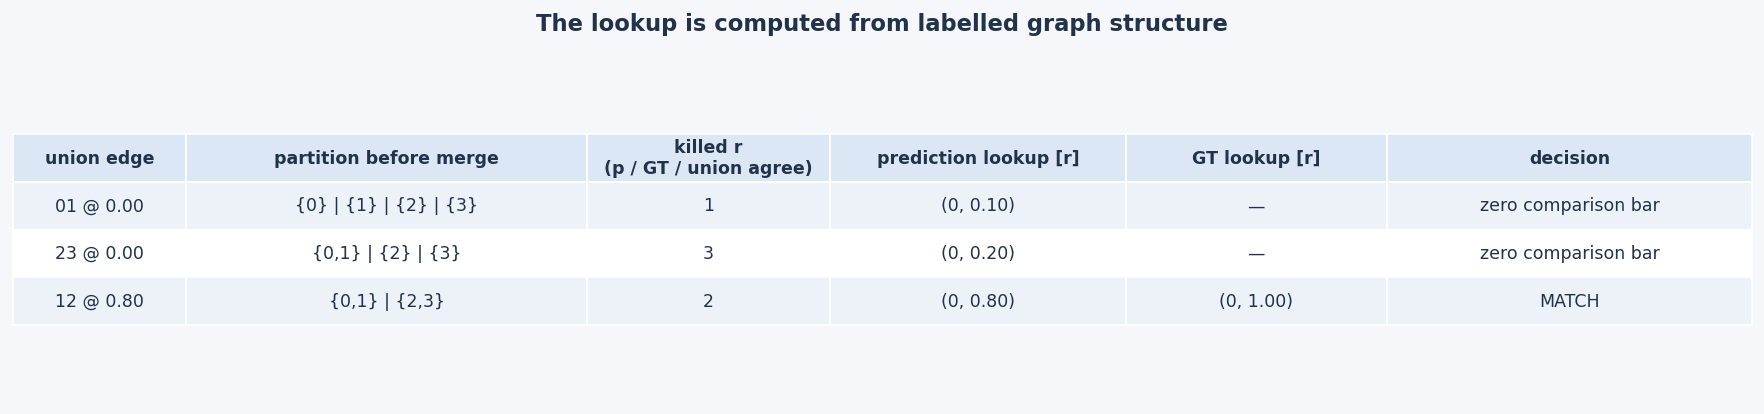

In [5]:
rows=[]
for x in M.trace:
    a,b=x["prediction"],x["target"]
    rows.append([f'{x["edge"][0]}{x["edge"][1]} @ {x["time"]:.2f}',
                 partition(x["before"]),str(x["rp"]),
                 "—" if a is None else f"(0, {a.death:.2f})",
                 "—" if b is None else f"(0, {b.death:.2f})",
                 "MATCH" if x["matched"] else "zero comparison bar"])
fig,ax=plt.subplots(figsize=(14,3.2),layout="constrained")
table(ax,["union edge","partition before merge","killed r\n(p / GT / union agree)",
          "prediction lookup [r]","GT lookup [r]","decision"],rows,
      "The lookup is computed from labelled graph structure",
      [.10,.23,.14,.17,.15,.21])
finish(fig,"04_lookup")

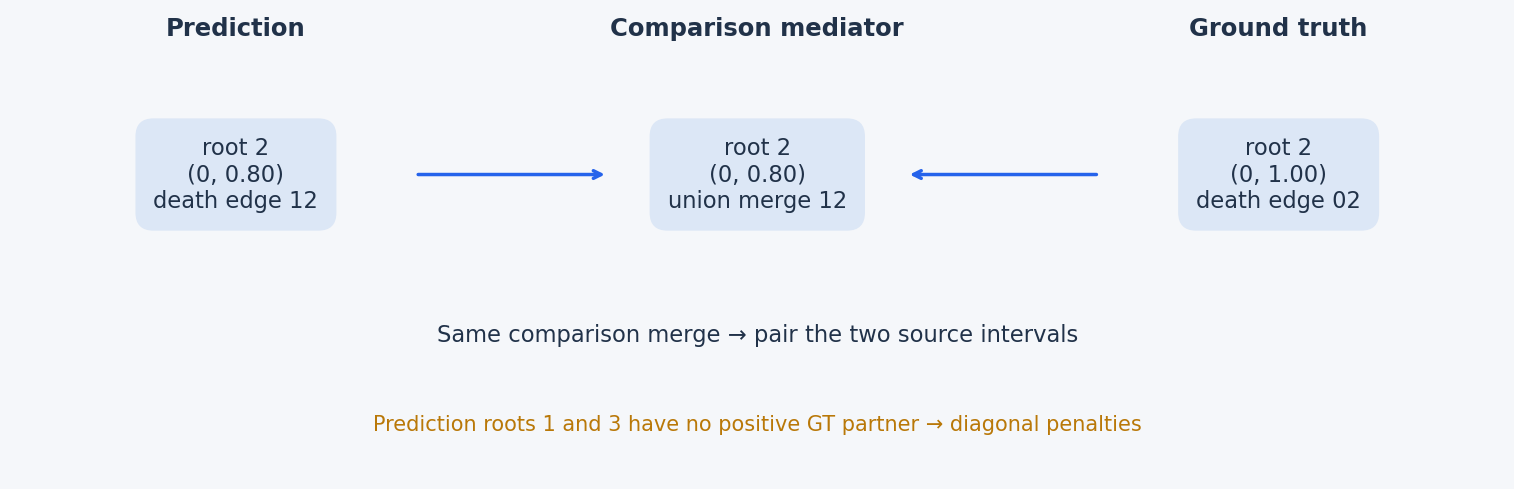

In [6]:
fig,ax=plt.subplots(figsize=(12,3.8),layout="constrained")
ax.set(xlim=(0,1),ylim=(0,1));ax.axis("off")
for x,title in ((.15,"Prediction"),(.5,"Comparison mediator"),(.85,"Ground truth")):
    ax.text(x,.95,title,ha="center",weight="bold",fontsize=14)
match=M.matches[0]
for x,text in ((.15,f"root {match.prediction.vertex}\n(0, {match.prediction.death:.2f})\ndeath edge 12"),
               (.5,f"root {match.comparison.vertex}\n(0, {match.comparison.death:.2f})\nunion merge 12"),
               (.85,f"root {match.target.vertex}\n(0, {match.target.death:.2f})\ndeath edge 02")):
    ax.text(x,.65,text,ha="center",va="center",fontsize=13,
            bbox=dict(boxstyle="round,pad=.8",fc="#dce7f6",ec="none"))
for x,y in ((.27,.40),(.73,.60)):
    ax.annotate("",xy=(y,.65),xytext=(x,.65),arrowprops=dict(arrowstyle="->",color=BLUE,lw=2))
ax.text(.5,.29,"Same comparison merge → pair the two source intervals",ha="center",fontsize=13)
ax.text(.5,.10,"Prediction roots 1 and 3 have no positive GT partner → diagonal penalties",
        ha="center",color=GOLD,fontsize=12)
finish(fig,"05_matching")

## 05 · The full loss, including edge 01

All births are zero. A matched pair costs \((d_p-d_{GT})^2\); an unmatched prediction pair costs \(d_p^2/2\).
“Unmatched” can mean a delayed connection inside a true vessel.

\[
L_{\rm raw}=\tfrac12(1-p_{01})^2+\tfrac12(1-p_{23})^2+p_{12}^2
           =0.005+0.020+0.040=0.065,\qquad
L_{H_0}=L_{\rm raw}/3=0.0216667.
\]

There are three counted features: one match and two unmatched prediction intervals. The previous \(0.08\) value used different vertex births and is no longer the objective.

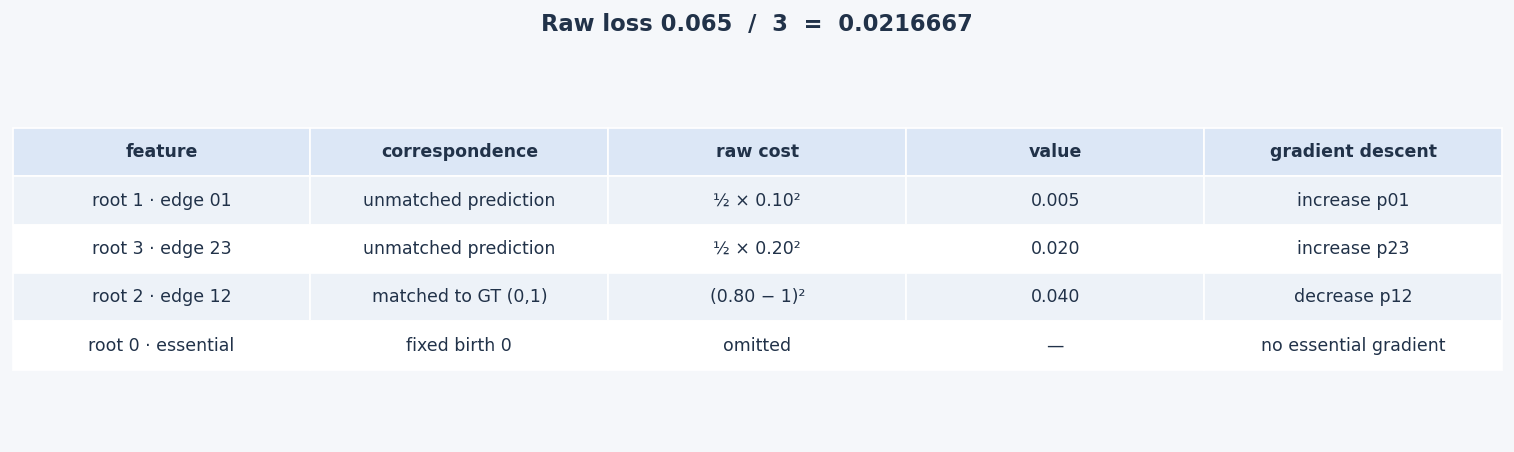

In [7]:
terms=loss_terms(M)
rows=[
    ["root 1 · edge 01","unmatched prediction","½ × 0.10²","0.005","increase p01"],
    ["root 3 · edge 23","unmatched prediction","½ × 0.20²","0.020","increase p23"],
    ["root 2 · edge 12","matched to GT (0,1)","(0.80 − 1)²","0.040","decrease p12"],
    ["root 0 · essential","fixed birth 0","omitted","—","no essential gradient"],
]
fig,ax=plt.subplots(figsize=(12,3.5),layout="constrained")
table(ax,["feature","correspondence","raw cost","value","gradient descent"],rows,
      f"Raw loss {scalar_loss(M,normalize=False):.3f}  /  3  =  {scalar_loss(M):.7f}")
finish(fig,"06_loss")

## 06 · Real backpropagation

Compute matching on detached values; evaluate the selected deaths on live tensors.
Left: derivatives with respect to probabilities. Right: derivatives with respect to binary log-odds \(z\), where \(p=\mathrm{sigmoid}(z)\). Gradient descent moves opposite to these bars.

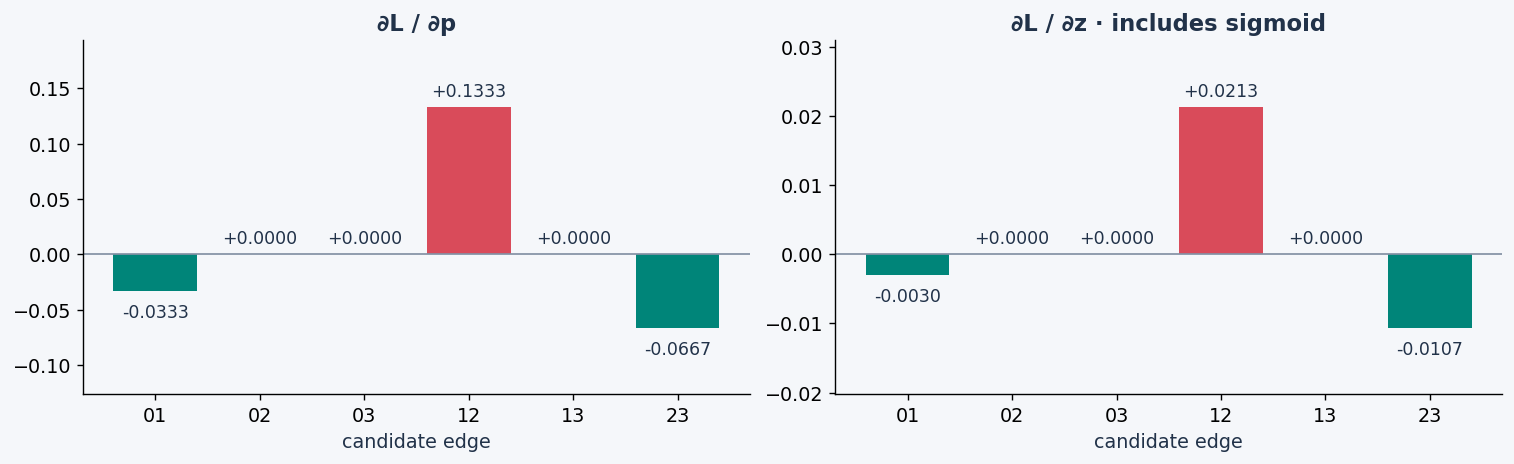

In [8]:
q=torch.tensor([EXAMPLE[e] for e in P.edges],dtype=torch.float64,requires_grad=True)
loss,_=differentiable_loss(q,E,TRUTH,num_vertices=4)
dp,=torch.autograd.grad(loss,q)
z=torch.logit(q.detach()).requires_grad_()
lz,_=differentiable_loss(z.sigmoid(),E,TRUTH,num_vertices=4)
dz,=torch.autograd.grad(lz,z)
assert torch.allclose(dp,torch.tensor([-.1/3,0,0,.4/3,0,-.2/3],dtype=q.dtype))
fig,axs=plt.subplots(1,2,figsize=(12,3.6),layout="constrained")
for ax,values,title in ((axs[0],dp,"∂L / ∂p"),(axs[1],dz,"∂L / ∂z · includes sigmoid")):
    values=values.numpy()
    ax.bar(labels,values,color=[TEAL if v<0 else RED if v>0 else GRAY for v in values])
    ax.axhline(0,color=GRAY,lw=1)
    ax.set_title(title)
    ax.set_xlabel("candidate edge")
    for i,v in enumerate(values):
        ax.annotate(f"{v:+.4f}",(i,v),xytext=(0,6 if v>=0 else -15),
                    textcoords="offset points",ha="center",fontsize=10)
    ax.margins(y=.30)
finish(fig,"07_gradients")

## 07 · Change only the target: the bridge gradient reverses

If GT is \(01\,|\,23\), edge \(12\) should weaken. If GT is the path \(0–1–2–3\), the same edge should strengthen.
The comparison filtration changes the matching and therefore the loss.

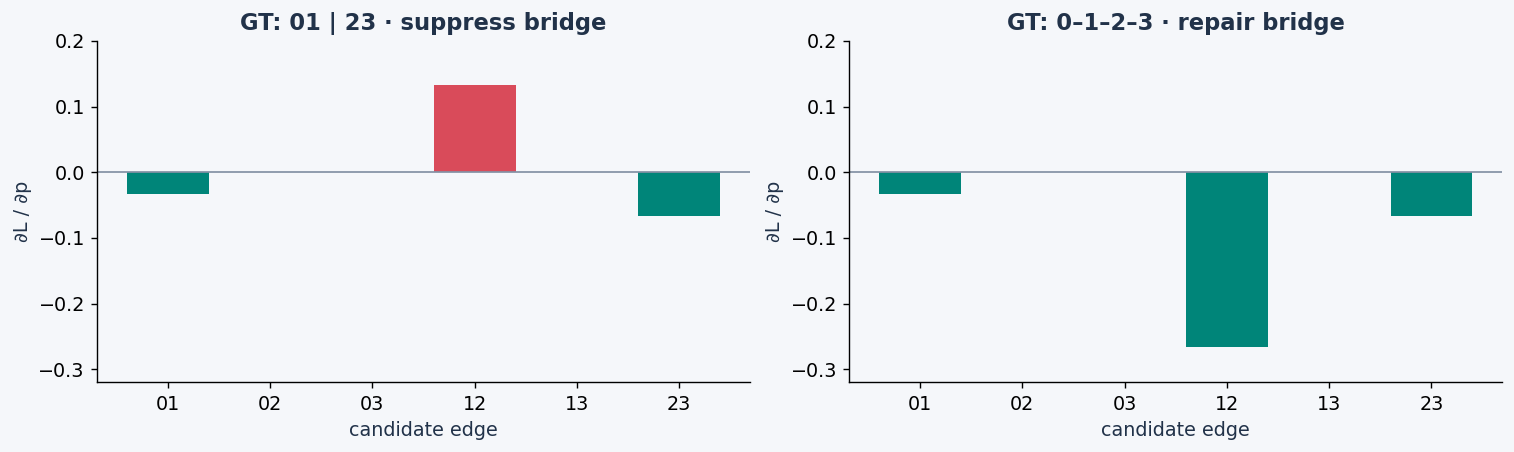

In [9]:
connected_truth=TRUTH|{(1,2)}
qc=q.detach().requires_grad_()
lc,mc=differentiable_loss(qc,E,connected_truth,num_vertices=4)
dpc,=torch.autograd.grad(lc,qc)
assert dp[3]>0 and dpc[3]<0
fig,axs=plt.subplots(1,2,figsize=(12,3.5),layout="constrained")
for ax,vals,title in ((axs[0],dp,"GT: 01 | 23 · suppress bridge"),(axs[1],dpc,"GT: 0–1–2–3 · repair bridge")):
    vals=vals.detach().numpy()
    ax.bar(labels,vals,color=[TEAL if v<0 else RED if v>0 else GRAY for v in vals])
    ax.axhline(0,color=GRAY,lw=1)
    ax.set_title(title);ax.set_xlabel("candidate edge")
    ax.set_ylim(-.32,.2);ax.set_ylabel("∂L / ∂p")
finish(fig,"08_target_changes_gradient")

## 08 · Same diagram coordinates can hide different graph structure

Swap the strong edges to \(02\) and \(13\). The ordinary predicted death multiset stays \(\{0.10,0.20,0.80\}\).
The comparison merge changes, so its selected prediction partner changes. Ties use fixed vertex IDs; we do not claim invariance to relabelling those IDs.

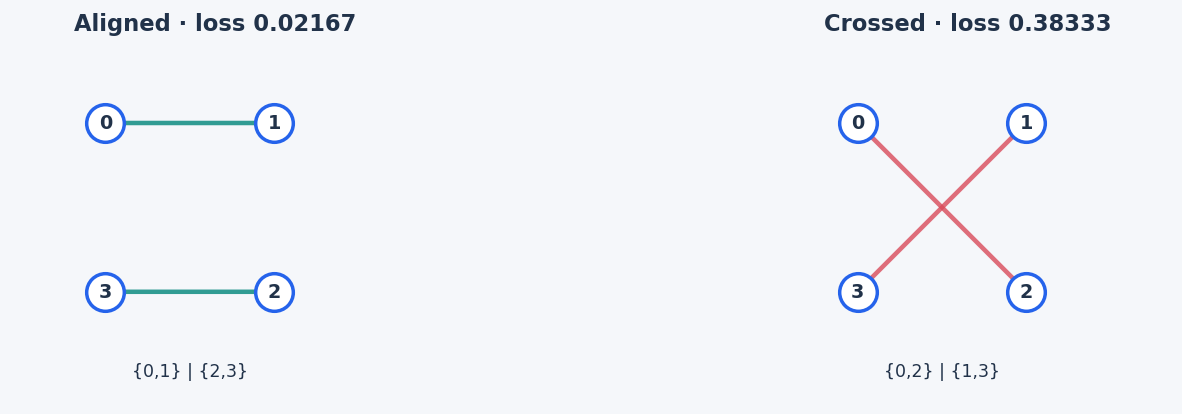

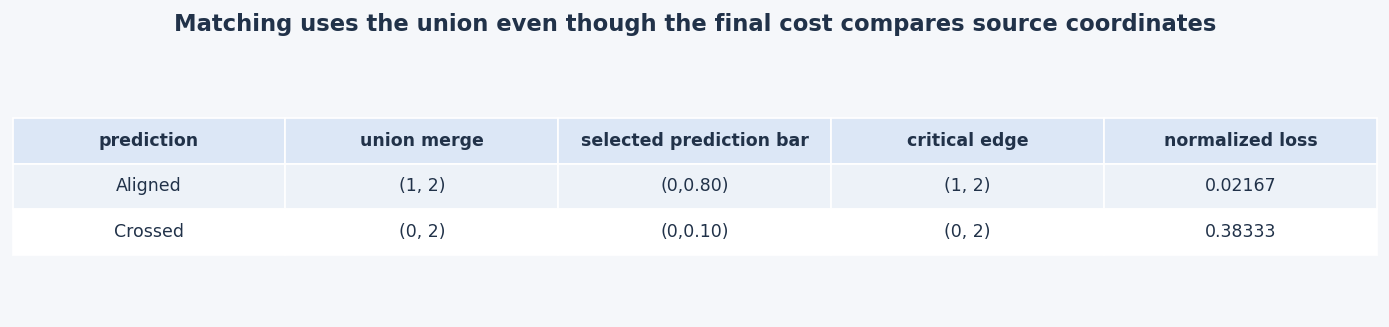

In [10]:
cross = from_probabilities(4,{(0,1):.10,(0,2):.90,(0,3):.02,(1,2):.20,(1,3):.80,(2,3):.05})
crossM=induced_matching(cross,target_graph(cross,TRUTH))
assert np.allclose(sorted(a.death for a in M.prediction.pairs),
                   sorted(a.death for a in crossM.prediction.pairs))
fig,axs=plt.subplots(1,2,figsize=(12,3.2),layout="constrained")
graph(axs[0],P,.5,f"Aligned · loss {scalar_loss(M):.5f}")
graph(axs[1],cross,.5,f"Crossed · loss {scalar_loss(crossM):.5f}")
finish(fig,"09_same_diagram")
rows=[]
for name,m in (("Aligned",M),("Crossed",crossM)):
    a=m.matches[0]
    rows.append([name,str(a.comparison.death_edge),f"(0,{a.prediction.death:.2f})",
                 str(a.prediction.death_edge),f"{scalar_loss(m):.5f}"])
fig,ax=plt.subplots(figsize=(11,2.5),layout="constrained")
table(ax,["prediction","union merge","selected prediction bar","critical edge","normalized loss"],rows,
      "Matching uses the union even though the final cost compares source coordinates")
finish(fig,"10_crossed_lookup")

## 09 · Low confidence: a hidden failure becomes visible

Three matched vertices; connected GT path \(0–1–2\); every candidate has \(p=0.10\).
Previously: vertices and edges entered together at \(0.90\), yielding no positive finite bars and zero loss.
With fixed births: two intervals \((0,0.90)\), normalized loss \(0.405\), and gradients toward stronger spanning edges. At exact ties the rule selects edges 01 and 02, although GT uses 01 and 12: BCE is still needed for exact edge identity.

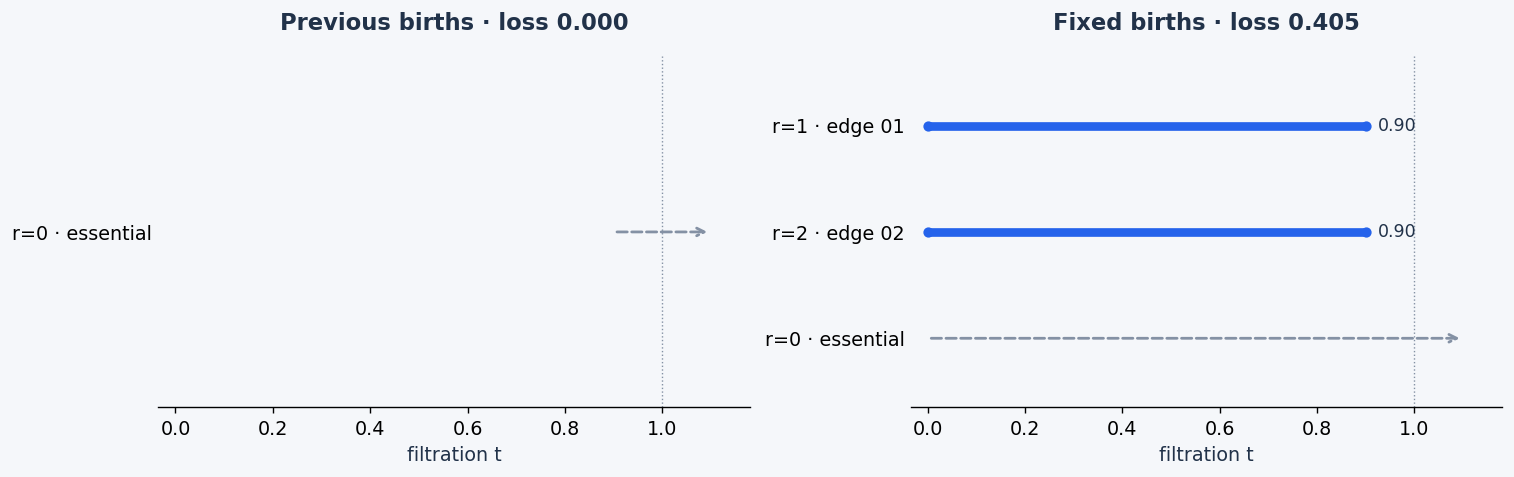

In [11]:
low_probs={e:.1 for e in complete_edges(3)}
low_old=from_probabilities(3,low_probs,vertex_mode="incident")
low_new=from_probabilities(3,low_probs)
lm_old=induced_matching(low_old,target_graph(low_old,{(0,1),(1,2)},vertex_mode="incident"))
lm_new=induced_matching(low_new,target_graph(low_new,{(0,1),(1,2)}))
assert scalar_loss(lm_old)==0 and np.isclose(scalar_loss(lm_new),.405)
fig,axs=plt.subplots(1,2,figsize=(12,3.7),layout="constrained")
bars(axs[0],lm_old.prediction,f"Previous births · loss {scalar_loss(lm_old):.3f}")
bars(axs[1],lm_new.prediction,f"Fixed births · loss {scalar_loss(lm_new):.3f}")
finish(fig,"11_uniform_low")

## 10 · Optimization after warmup: observe a false bridge

This toy experiment optimizes six independent binary log-odds, not RelationFormer.
Both runs start with a false bridge \(p_{12}=0.65\). They use the same BCE and SGD; one adds the normalized H₀ loss after step 40, ramping its weight to 2 by step 80. The illustrative weight is not a training recommendation.

Blue shading marks warmup; the dotted line marks the end of the ramp. In this easy example BCE already restores two components during warmup. H₀ subsequently increases the confidence margin; these curves do not demonstrate better component counts than BCE.

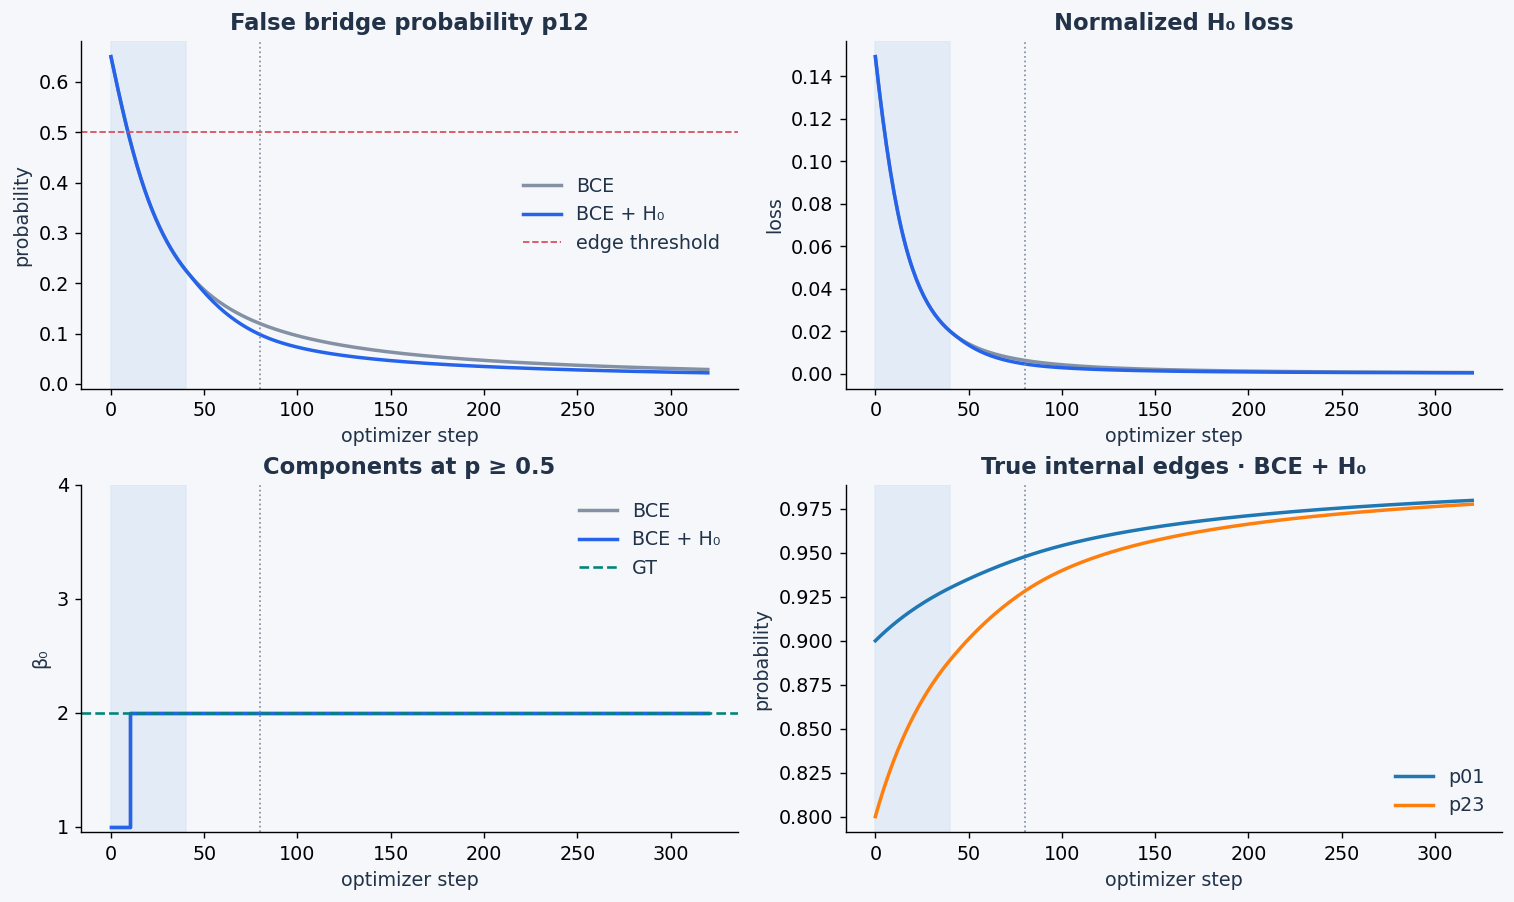

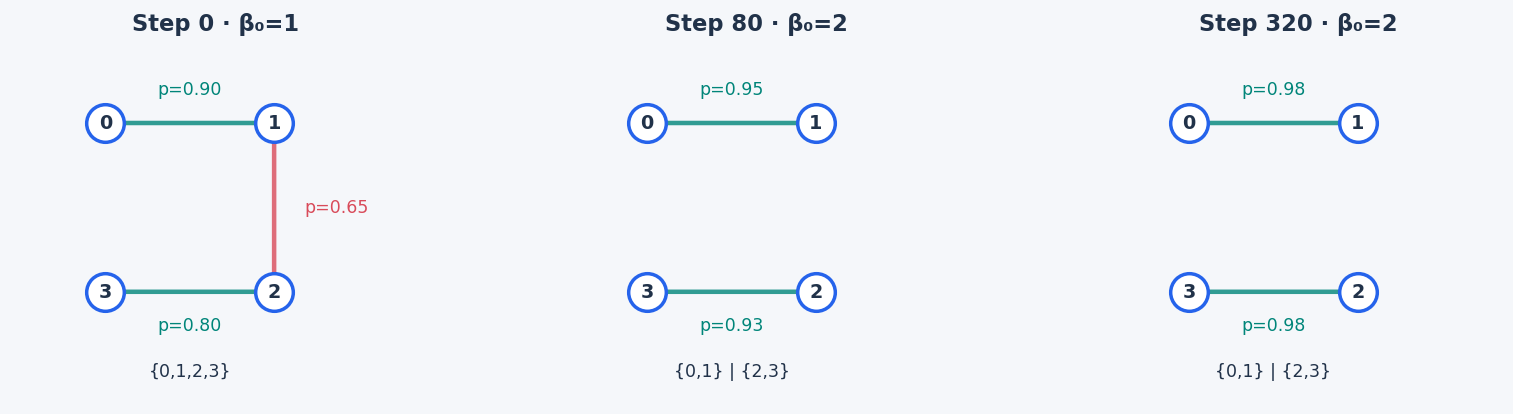

In [12]:
def run_training(topology=True, steps=320):
    initial=q.detach().clone(); initial[3]=.65
    logits=torch.logit(initial).requires_grad_()
    labels_t=torch.tensor([float(e in TRUTH) for e in P.edges],dtype=torch.float64)
    optimizer=torch.optim.SGD([logits],lr=.7)
    history={"p":[],"bce":[],"h0":[],"weight":[],"beta0":[]}
    for step in range(steps+1):
        prob=logits.sigmoid()
        ce=torch.nn.functional.binary_cross_entropy_with_logits(logits,labels_t)
        h0,_=differentiable_loss(prob,E,TRUTH,num_vertices=4)
        weight=2*min(1.,max(0.,(step-40)/40)) if topology else 0.
        values=prob.detach().numpy().copy()
        gg=from_probabilities(4,dict(zip(P.edges,values)))
        history["p"].append(values)
        history["bce"].append(ce.item());history["h0"].append(h0.item())
        history["weight"].append(weight);history["beta0"].append(len(components_at(gg,.5)))
        if step<steps:
            optimizer.zero_grad()
            (ce+weight*h0).backward()
            optimizer.step()
    return {k:np.asarray(v) for k,v in history.items()}
baseline=run_training(False)
combined=run_training(True)
assert np.allclose(baseline["p"][:41],combined["p"][:41])
assert combined["h0"][-1] < combined["h0"][0]
fig,axs=plt.subplots(2,2,figsize=(12,7.1),layout="constrained")
for data,name,color in ((baseline,"BCE",GRAY),(combined,"BCE + H₀",BLUE)):
    axs[0,0].plot(data["p"][:,3],label=name,color=color,lw=2)
    axs[0,1].plot(data["h0"],label=name,color=color,lw=2)
    axs[1,0].step(np.arange(len(data["beta0"])),data["beta0"],where="post",label=name,color=color,lw=2)
for ax in axs.flat:
    ax.axvspan(0,40,color="#dce7f6",alpha=.7)
    ax.axvline(80,color=GRAY,ls=":",lw=1)
    ax.set_xlabel("optimizer step")
axs[0,0].axhline(.5,color=RED,ls="--",lw=1,label="edge threshold")
axs[0,0].set(title="False bridge probability p12",ylabel="probability")
axs[0,0].legend(frameon=False)
axs[0,1].set(title="Normalized H₀ loss",ylabel="loss")
axs[1,0].axhline(2,color=TEAL,ls="--",label="GT")
axs[1,0].set(title="Components at p ≥ 0.5",ylabel="β₀",yticks=[1,2,3,4])
axs[1,0].legend(frameon=False)
for i in (0,5):
    axs[1,1].plot(combined["p"][:,i],label=f"p{labels[i]}",lw=2)
axs[1,1].set(title="True internal edges · BCE + H₀",ylabel="probability")
axs[1,1].legend(frameon=False)
finish(fig,"12_training")
fig,axs=plt.subplots(1,3,figsize=(13,3.2),layout="constrained")
for ax,step in zip(axs,(0,80,320)):
    gg=from_probabilities(4,dict(zip(P.edges,combined["p"][step])))
    graph(ax,gg,.5,f"Step {step} · β₀={combined['beta0'][step]}",True)
finish(fig,"13_training_graphs")

## 11 · What the tests establish

The assertions below check the example arithmetic, persistence against an independent GF(2) boundary reduction, finite differences, edge-order invariance and backpropagation through a two-order relation head. They also check isolated target vertices and the low-confidence case.

These are implementation checks for the chosen labelled refinement. They do not establish generalization or a unique correspondence under vertex relabelling.

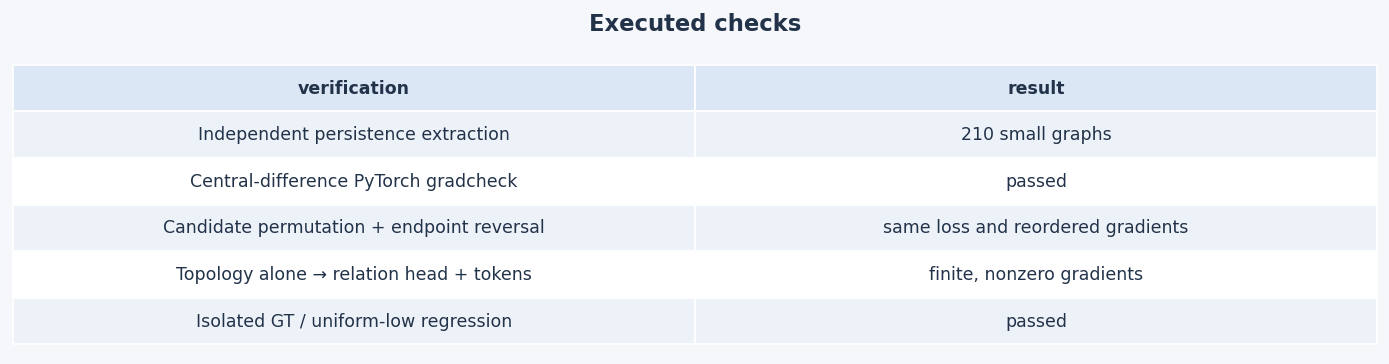

In [13]:
checks=self_check()
fig,ax=plt.subplots(figsize=(11,2.8),layout="constrained")
rows=[["Independent persistence extraction",f"{checks['boundary_reduction_cases']} small graphs"],
      ["Central-difference PyTorch gradcheck","passed"],
      ["Candidate permutation + endpoint reversal","same loss and reordered gradients"],
      ["Topology alone → relation head + tokens","finite, nonzero gradients"],
      ["Isolated GT / uniform-low regression","passed"]]
table(ax,["verification","result"],rows,"Executed checks")
finish(fig,"14_checks")

**Training interpretation.** Fixed vertices expose connectivity delays, including missing leaf connections. Only selected merge edges receive H₀ gradients in a given pass; edge BCE remains responsible for exact relations, and H₁ for loops. Matching and normalization are recomputed each forward pass.

**Tie convention.** Vertices tie by ID; edges tie by canonical endpoint IDs. Tied gradients need not be unique. Labels are fixed across prediction, GT and comparison.

**Source.** Graph specialization of the refined/extended H₀ construction in [Stucki et al., ICML 2023, Appendix C](https://proceedings.mlr.press/v202/stucki23a/stucki23a.pdf). The fixed-vertex filtration is the design choice explored here. Executable formulas, tracing metadata, PyTorch adapter and checks are in \`graph_h0_fixed_births.py\`.